# AppleSupport Data Analysis

In [6]:
import pandas as pd

# Configuration
INPUT_FILE = "/content/apple_support.csv"

# Load the dataset
apple_df = pd.read_csv(INPUT_FILE)

print(f"Successfully loaded {INPUT_FILE}!")

Successfully loaded /content/apple_support.csv!


## A. DATASET OVERVIEW

In [7]:
# Number of rows and columns
num_rows, num_cols = apple_df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

# Column names and data types
print("\nColumn names and data types:")
display(apple_df.info())

# Missing values
print("\nMissing values per column:")
display(apple_df.isnull().sum())

# Duplicate tweet IDs
duplicate_tweet_ids = apple_df['tweet_id'].duplicated().sum()
print(f"\nNumber of duplicate tweet IDs: {duplicate_tweet_ids}")

# Drop duplicates to avoid issues in further analysis if any
if duplicate_tweet_ids > 0:
    print("Dropping duplicate tweet IDs.")
    apple_df.drop_duplicates(subset=['tweet_id'], inplace=True)
    print(f"Number of rows after dropping duplicates: {apple_df.shape[0]}")

# Unique customer count
# A customer is identified by 'author_id' when 'inbound' is True and they are not AppleSupport
# Assuming AppleSupport is the only company, its author_id is 'AppleSupport' or equivalent.
# We need to ensure we don't count the company as a customer.
company_author_id = 'AppleSupport' # Assuming this is consistent

customer_tweets = apple_df[(apple_df['inbound'] == True) & (apple_df['author_id'] != company_author_id)]
unique_customer_count = customer_tweets['author_id'].nunique()
print(f"\nNumber of unique customer IDs: {unique_customer_count}")

# Company/support tweet count
company_tweet_count = apple_df[apple_df['author_id'] == company_author_id].shape[0]
print(f"Number of company ({company_author_id}) tweets: {company_tweet_count}")

# Customer tweet count (total tweets from customers)
customer_total_tweet_count = customer_tweets.shape[0]
print(f"Total customer tweets: {customer_total_tweet_count}")

Number of rows: 204772
Number of columns: 7

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204772 entries, 0 to 204771
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   tweet_id                 204772 non-null  int64  
 1   author_id                204772 non-null  object 
 2   inbound                  204772 non-null  bool   
 3   created_at               204772 non-null  object 
 4   text                     204772 non-null  object 
 5   response_tweet_id        116008 non-null  object 
 6   in_response_to_tweet_id  153114 non-null  float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 9.6+ MB


None


Missing values per column:


,0
tweet_id,0
author_id,0
inbound,0
created_at,0
text,0
response_tweet_id,88764
in_response_to_tweet_id,51658



Number of duplicate tweet IDs: 0

Number of unique customer IDs: 58578
Number of company (AppleSupport) tweets: 106860
Total customer tweets: 97896


## B. CONVERSATION STRUCTURE

In [8]:
# Convert 'created_at' to datetime objects
apple_df['created_at'] = pd.to_datetime(apple_df['created_at'], errors='coerce')

# Drop rows where 'created_at' could not be parsed
apple_df.dropna(subset=['created_at'], inplace=True)

# Helper function to reconstruct a conversation thread
def get_conversation_thread(df, initial_tweet_id):
    thread_tweets = []
    current_tweet_id = initial_tweet_id

    # Start with the initial tweet
    initial_tweet = df[df['tweet_id'] == initial_tweet_id]
    if initial_tweet.empty:
        return None
    thread_tweets.append(initial_tweet.iloc[0])

    # Recursively find replies and responses
    q = [initial_tweet_id]
    visited = {initial_tweet_id}

    while q:
        parent_id = q.pop(0)

        # Find direct replies to the current parent_id
        # A tweet is a reply if its 'in_response_to_tweet_id' matches the parent_id
        direct_replies = df[df['in_response_to_tweet_id'] == parent_id]

        for idx, reply in direct_replies.iterrows():
            if reply['tweet_id'] not in visited:
                thread_tweets.append(reply)
                visited.add(reply['tweet_id'])
                q.append(reply['tweet_id'])

    # Convert list of Series to DataFrame and sort by time
    thread_df = pd.DataFrame(thread_tweets).sort_values(by='created_at').reset_index(drop=True)

    return thread_df

# Identify initial customer inquiries
# These are tweets from customers (inbound=True) that are not in response to any other tweet (in_response_to_tweet_id is null or NaN)
initial_inquiries = apple_df[
    (apple_df['inbound'] == True) &
    (apple_df['in_response_to_tweet_id'].isnull())
].copy()

# Store conversation details
conversation_threads_data = []

# For efficiency, iterate over a sample or the most recent initial inquiries if the dataset is too large
# Here, I'll process a reasonable number of threads to demonstrate the structure.
# You might want to adjust `initial_inquiries_sample_size` based on performance.
initial_inquiries_sample_size = 500 # Adjust as needed

for idx, inquiry in initial_inquiries.head(initial_inquiries_sample_size).iterrows():
    thread_df = get_conversation_thread(apple_df, inquiry['tweet_id'])

    if thread_df is not None and not thread_df.empty:
        thread_length = len(thread_df)
        num_customer_messages = thread_df[thread_df['inbound'] == True].shape[0]
        num_applesupport_messages = thread_df[thread_df['author_id'] == 'AppleSupport'].shape[0]

        conversation_threads_data.append({
            'initial_inquiry_id': inquiry['tweet_id'],
            'thread_length': thread_length,
            'num_customer_messages': num_customer_messages,
            'num_applesupport_messages': num_applesupport_messages,
            'thread_df': thread_df
        })

print(f"Analyzed {len(conversation_threads_data)} conversation threads.\n")

# Convert to DataFrame for easier analysis
conversation_summary_df = pd.DataFrame([
    {
        'initial_inquiry_id': d['initial_inquiry_id'],
        'thread_length': d['thread_length'],
        'num_customer_messages': d['num_customer_messages'],
        'num_applesupport_messages': d['num_applesupport_messages']
    }
    for d in conversation_threads_data
])

# Distribution of thread lengths
print("Distribution of thread lengths:")
display(conversation_summary_df['thread_length'].value_counts().sort_index())

# Median thread length
median_thread_length = conversation_summary_df['thread_length'].median()
print(f"\nMedian thread length: {median_thread_length}")

# Longest threads
print("\nLongest threads (top 5 by length):")
longest_threads = conversation_summary_df.sort_values(by='thread_length', ascending=False).head(5)
display(longest_threads)

# Display a few real example conversations (e.g., the top 3 longest ones)
print("\n--- Example Conversations ---")
for idx, row in longest_threads.iterrows():
    initial_id = row['initial_inquiry_id']
    thread = next(item for item in conversation_threads_data if item['initial_inquiry_id'] == initial_id)
    print(f"\nConversation starting with tweet_id: {initial_id} (Length: {row['thread_length']})")
    for t_idx, t_row in thread['thread_df'].iterrows():
        prefix = "Customer:" if t_row['inbound'] else "AppleSupport:"
        cleaned_text = t_row['text'].replace('\n', ' ').strip()
        in_response_to = f" (In response to: {t_row['in_response_to_tweet_id']:.0f})" if pd.notna(t_row['in_response_to_tweet_id']) else ""
        print(f"{prefix} {cleaned_text}{in_response_to}")

/tmp/ipykernel_452/2469604161.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  apple_df['created_at'] = pd.to_datetime(apple_df['created_at'], errors='coerce')


Analyzed 500 conversation threads.

Distribution of thread lengths:


,count
thread_length,
1,5
2,238
3,38
4,104
5,29
6,34
7,16
8,19
9,9



Median thread length: 3.0

Longest threads (top 5 by length):


,initial_inquiry_id,thread_length,num_customer_messages,num_applesupport_messages
210,26714,14,9,5
193,23111,12,7,5
389,38645,11,6,5
376,37656,10,5,5
286,34610,10,8,2



--- Example Conversations ---

Conversation starting with tweet_id: 26714 (Length: 14)
Customer: @115948 @AppleSupport help? https://t.co/jq11xG12w0
AppleSupport: @121850 We're here to help in any way we can. Since we offer support in English, could you let us know what the message says? (In response to: 26714)
Customer: @AppleSupport Yes thank you! So I downloaded "Harry Styles: Behind the Album/ Behind the Music Video" in May. And now suddenly I just can't watch it (In response to: 26710)
Customer: @AppleSupport When I click on the video the message "Object isn't available. This object can't be played/reproduced" appears. (In response to: 26710)
Customer: @AppleSupport And when I search for it in the regular store it doesn't even show up anymore (In response to: 26710)
Customer: @AppleSupport And I'm confused because I've already watched it multiple times since may and I had downloaded it so how come I can't watch it anymore? (In response to: 26710)
AppleSupport: @121850 Are you abl

In [9]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print("NLTK setup completed")

NLTK setup completed


In [11]:
import re
import pandas as pd

customer_df = apple_df[apple_df["inbound"] == True].copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = [
        word for word in text.split()
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

customer_df["clean_text"] = customer_df["text"].apply(clean_text)

display(customer_df[["tweet_id", "text", "clean_text"]].head(20))

,tweet_id,text,clean_text
1,697,@AppleSupport The newest update. I️ made sure ...,newest update made sure download yesterday
3,698,@AppleSupport https://t.co/NV0yucs0lB,
4,700,@AppleSupport why are my I️’s changing not sho...,changing showing correctly social media platforms
6,702,@AppleSupport Tried resetting my settings .. r...,tried resetting settings restarting phone
8,704,@AppleSupport This is what it looks like https...,looks like
10,707,@AppleSupport I️ have an iPhone 7 Plus and yes...,iphone plus yes
12,709,@AppleSupport I️ need answers because it’s ann...,need answers annoying
14,713,@AppleSupport Just sent you all my DM,sent
15,714,Hey @AppleSupport and anyone else who upgraded...,hey anyone else upgraded ios11 issues capital ...
17,717,@AppleSupport This is what is happening... htt...,happening


## C. CUSTOMER MESSAGE ANALYSIS

Cleaning customer messages...

Top 20 meaningful keywords:
- iphone: 17723
- ios: 17665
- phone: 15783
- update: 11084
- fix: 8063
- battery: 6653
- cant: 5800
- app: 4973
- since: 4745
- screen: 4235
- work: 3878
- apps: 3826
- updated: 3768
- dont: 3724
- doesnt: 3263
- amp: 3202
- music: 3062
- every: 2973
- working: 2967
- wont: 2820

Top 15 common bigrams:
- ios update: 1746
- iphone plus: 1744
- battery life: 1342
- doesnt work: 1039
- iphone ios: 967
- updated ios: 872
- question mark: 835
- ios iphone: 798
- high sierra: 797
- ever since: 791
- since ios: 677
- updated phone: 639
- app store: 610
- since update: 606
- since updated: 604

Top 15 common trigrams:
- ever since updated: 243
- question mark box: 236
- since updated ios: 233
- since ios update: 231
- latest ios update: 205
- iphone plus ios: 175
- phone keeps freezing: 158
- since updating ios: 153
- gon na fix: 151
- macos high sierra: 148
- cant type letter: 124
- ever since update: 117
- ios iphone plus: 113
- sin

/tmp/ipykernel_452/2212924207.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Keyword', data=keyword_df, palette='viridis')


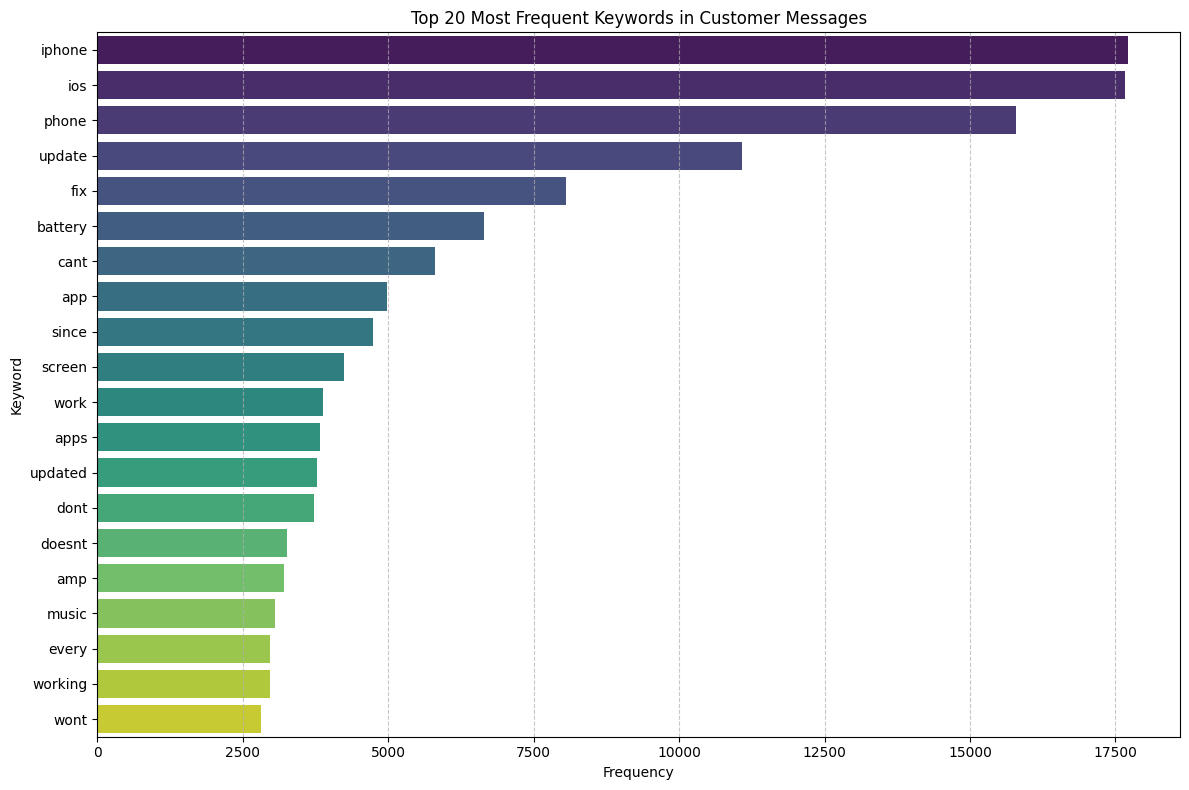

In [12]:
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuration - Redefine INPUT_FILE and load apple_df to ensure it's available
INPUT_FILE = "/content/apple_support.csv"
# Load the dataset if it's not already defined
if 'apple_df' not in locals() and 'apple_df' not in globals():
    try:
        apple_df = pd.read_csv(INPUT_FILE)
        print("apple_df loaded successfully within this cell.")
    except FileNotFoundError:
        print(f"Error: {INPUT_FILE} not found. Please ensure the file exists.")
        # Exit or handle error appropriately if file is crucial
        raise # Re-raise if file is critical

# Download necessary NLTK data (if not already downloaded)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Ensure 'punkt' tokenizer data is available
try:
    # This checks for the main Punkt tokenizer data for English
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except LookupError:
    nltk.download('punkt')

# Ensure 'punkt_tab' tokenizer data is available, as word_tokenize might implicitly rely on it
# The error message directly points to 'punkt_tab' not being found.
try:
    # Check if the 'punkt_tab' resource directory for English exists
    nltk.data.find('tokenizers/punkt_tab/english/')
except LookupError:
    # If not found, download it
    nltk.download('punkt_tab')


# Filter for inbound customer messages only
customer_inbound_messages = apple_df[apple_df['inbound'] == True].copy()

# Define English stopwords
stop_words = set(stopwords.words('english'))
# Add custom stopwords relevant to customer support interactions that are not indicative of an issue
custom_stopwords = set([
    'apple', 'support', 'applesupport', 'https', 't.co', 'co', 'just', 'get', 'can', 'will', 'need', 'help', 'please',
    'thank', 'thanks', 'im', 'ive', 'would', 'should', 'could', 'know', 'want', 'don', 'really', 'much', 'like',
    'call', 'dm', 'us', 'back', 'message', 'see', 'sent', 'new', 'still', 'go', 'try', 'look', 'make', 'one', 'good',
    'say', 'said', 'get', 'getting', 'ask', 'even', 'got', 'day', 'time', 'first', 'also', 'problem', 'issues', 'issue'
])
stop_words = stop_words.union(custom_stopwords)

# Text cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize words
    words = word_tokenize(text)
    # Remove stopwords and single-character words
    words = [word for word in words if word not in stop_words and len(word) > 1]
    return " ".join(words)

print("Cleaning customer messages...")
customer_inbound_messages['cleaned_text'] = customer_inbound_messages['text'].apply(clean_text)

# Combine all cleaned text for word analysis
all_cleaned_text = ' '.join(customer_inbound_messages['cleaned_text'].dropna().tolist())
words = all_cleaned_text.split()

# Top meaningful keywords
word_counts = Counter(words)
print("\nTop 20 meaningful keywords:")
for word, count in word_counts.most_common(20):
    print(f"- {word}: {count}")

# Common bigrams and trigrams
# Function to generate n-grams
def generate_ngrams(text_list, n):
    ngrams = []
    for text in text_list:
        tokens = text.split()
        if len(tokens) >= n:
            ngrams.extend(list(nltk.ngrams(tokens, n)))
    return ngrams

# Generate bigrams
bigrams = generate_ngrams(customer_inbound_messages['cleaned_text'].dropna().tolist(), 2)
bigram_counts = Counter(bigrams)
print("\nTop 15 common bigrams:")
for bigram, count in bigram_counts.most_common(15):
    print(f"- {' '.join(bigram)}: {count}")

# Generate trigrams
trigrams = generate_ngrams(customer_inbound_messages['cleaned_text'].dropna().tolist(), 3)
trigram_counts = Counter(trigrams)
print("\nTop 15 common trigrams:")
for trigram, count in trigram_counts.most_common(15):
    print(f"- {' '.join(trigram)}: {count}")

# Representative customer messages for top keywords
print("\n--- Representative Customer Messages ---")
# For top 5 keywords, find a few original messages
example_keywords = [word for word, count in word_counts.most_common(5)]

for keyword in example_keywords:
    print(f"\nMessages containing '{keyword}':")
    # Find original tweets that contain the keyword (case-insensitive)
    sample_messages = customer_inbound_messages[
        customer_inbound_messages['text'].str.contains(keyword, case=False, na=False)
    ]['text'].head(3).tolist()
    if sample_messages:
        for msg in sample_messages:
            print(f"- {msg.replace('\n', ' ').strip()}")
    else:
        print("No examples found.")

# Get the top 20 meaningful keywords and their counts
top_keywords = word_counts.most_common(20)
keyword_df = pd.DataFrame(top_keywords, columns=['Keyword', 'Count'])

# Create a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Keyword', data=keyword_df, palette='viridis')
plt.title('Top 20 Most Frequent Keywords in Customer Messages')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## D. VISUALIZING KEY CUSTOMER INQUIRIES

In [13]:
# The plotting code has been moved to the previous cell (95f2f893) to ensure `word_counts` is defined.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import pandas as pd

# Use a manageable sample for intent discovery
sample_size = min(20000, len(customer_df))

intent_sample = customer_df.sample(
    n=sample_size,
    random_state=42
).copy()

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5
)

X = vectorizer.fit_transform(
    intent_sample["clean_text"].fillna("")
)

print("Sample size:", len(intent_sample))
print("Feature matrix:", X.shape)

Sample size: 20000
Feature matrix: (20000, 5000)


In [15]:
K = 10

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

intent_sample["cluster"] = kmeans.fit_predict(X)

print(intent_sample["cluster"].value_counts().sort_index())

cluster
0      382
1      271
2      163
3     2342
4     1941
5      680
6     1363
7    10104
8      988
9     1766
Name: count, dtype: int64


In [16]:
terms = vectorizer.get_feature_names_out()

for cluster_id in range(K):

    cluster_rows = intent_sample[
        intent_sample["cluster"] == cluster_id
    ]

    center = kmeans.cluster_centers_[cluster_id]

    top_indices = center.argsort()[-10:][::-1]

    top_terms = [
        terms[i]
        for i in top_indices
    ]

    print("\n" + "=" * 70)
    print(f"CLUSTER {cluster_id}")
    print("Size:", len(cluster_rows))
    print("Top terms:", ", ".join(top_terms))

    print("\nExamples:")

    for text in cluster_rows["text"].head(5):
        print("-", text)


CLUSTER 0
Size: 382
Top terms: thanks, thanks help, sent, thanks much, reply, thanks apple, much, help, thanks reply, worked

Examples:
- @AppleSupport I finally got a reply to my DM. Thanks!
- @AppleSupport Thanks!!!
- @AppleSupport Thanks! It fixed it
- @AppleSupport Thanks 🙏🏼
- @AppleSupport Thanks, yes I know that. But I want to share the email as a PDF. Is there a way of doing that? Thanks :)

CLUSTER 1
Size: 271
Top terms: thank, thank much, much, worked thank, worked, okay, got, great, done, thank help

Examples:
- @AppleSupport Okay thank you....
- @AppleSupport Thank you were right.
- @AppleSupport Thank you so much 😊
- @AppleSupport Ok thank you
- @AppleSupport Thank you!

CLUSTER 2
Size: 163
Top terms: yes, yes yes, right, questions, thanks, yes still, happening, still, work, good

Examples:
- @245886 @AppleSupport Yes right without the password,
- @AppleSupport yes and yes, started yesterday with my new iphone.
- @AppleSupport Yes
- @AppleSupport Yes, it’s turned on https: